## Supplementary Figure 6

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/supp_fig6_learning_ie/`: I-to-E plasticity followed by trajectory learning, 5 seeds
- `out/fig4_bcp/`: networks with analytic I-to-E weights (Figure 4 networks), 5 seeds

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import sys
from functools import partial
from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp
from diffrax import diffeqsolve, ODETerm, SaveAt, Euler, ConstantStepSize

import matplotlib as mpl
import matplotlib.pyplot as plt
import spiffyplots
from spiffyplots import MultiPanel
from matplotlib.colors import to_rgba
from cmcrameri import cm as cmc

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",})

from bcp.analysis import HydraRunOutput, HydraMultirun, rebuild_traj_run

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())
sys.path.insert(0, str(repo_root))
from run_traj import SimulationRunner

#### Directory setup

In [2]:
learned_dir = repo_root / "out" / "supp_fig6_learning_ie"
analytic_dir = repo_root / "out" / "fig4_bcp"
shapes_dir = repo_root / "data" / "shapes"

sfig6_dir = repo_root / "figures" / "supp_fig6"
sfig6_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [3]:
cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_inh = '#0077B8'
color_inh_ff = '#57CAF1'
color_inputs = '#808285'
color_openloop = 'gray'
color_closedloop = '#F49F1E'
color_target = 'black'
color_accent = 'black'
color_shading = 'gray'

linewidth = 1.0

### Load runs

In [4]:
SEEDS = [1, 2, 3, 4, 5]
PRETRAIN = '00_wie_pretrain'
MAIN = '01_main'

In [5]:
phase_results, phase_states = {}, {}
for seed in SEEDS:
    run = HydraRunOutput(learned_dir / f"seed{seed}")
    phase_results[seed] = run.load_pickle('phase_results.pkl')
    phase_states[seed] = run.load_pickle('phase_final_states.pkl')

learned_R2s = np.array([phase_results[s][MAIN]['OL_R2'][-1] for s in SEEDS])
analytic_R2s = np.array([HydraRunOutput(analytic_dir / f"seed{s}").load_pickle('results.pkl')['OL_R2'][-1]
                         for s in SEEDS])
print('Learned final OL R2s:', learned_R2s)
print('Analytic final OL R2s:', analytic_R2s)

Learned final OL R2s: [0.98979878 0.99053121 0.99038428 0.99367529 0.99428517]
Analytic final OL R2s: [0.99785638 0.99730289 0.99670058 0.99850559 0.9967103 ]


### Balance error with learned, analytic and shuffled I-to-E weights

In [6]:
SHUFFLE_SEED_OFFSET = 17

In [7]:
def rollout_balance_error(vf, sim, task, state, cfg, phase_iter):
    # one trajectory of burn-in, mean |Delta| over the next
    _, _, x1_interp, _ = task.simulate()
    state_eval, _ = sim.run_mode(dict(state), x1_interp, None, sim.mode_open_loop,
                                 save_final_only=False, phase_iter=phase_iter)
    x2, y2, x2_interp, _ = task.simulate()
    _, sol = sim.run_mode(state_eval, x2_interp, None, sim.mode_open_loop,
                          save_final_only=False, phase_iter=phase_iter)
    results = vf.analyze_run(x2, sol, cfg.dt, cfg.rec_dt, y2, closedloop=False,
                             phase_iter=phase_iter, W_IE_override=state_eval.get("W_IE", None))
    return float(np.mean(np.abs(np.asarray(results["error_hidden"]))))


balance_error = {'learned': [], 'analytic': [], 'shuffled': []}
learned_wie, analytic_wie = {}, {}
for seed in SEEDS:
    cfg, task, vf = rebuild_traj_run(HydraRunOutput(learned_dir / f"seed{seed}"), shapes_dir)
    sim = SimulationRunner(vf, Euler(), ConstantStepSize(), cfg.dt, cfg.rec_dt, cfg.T)
    phase_iter = int(cfg.training_phases[0].iterations) - 1

    state = phase_states[seed][PRETRAIN]
    learned_wie[seed] = np.asarray(state["W_IE"])
    analytic_wie[seed] = np.asarray(vf.W_IE_analytic)
    # shuffle across E neurons: keeps the weight distribution, breaks E alignment
    shuffled_cols = np.random.default_rng(seed + SHUFFLE_SEED_OFFSET).permutation(analytic_wie[seed].shape[1])

    for name, W_IE in [('learned', learned_wie[seed]), ('analytic', analytic_wie[seed]),
                       ('shuffled', analytic_wie[seed][:, shuffled_cols])]:
        balance_error[name].append(
            rollout_balance_error(vf, sim, task, {**state, "W_IE": W_IE}, cfg, phase_iter))
    jax.clear_caches()

    print(f"seed {seed} | |Delta| " + ", ".join(f"{k}={v[-1]:.6f}" for k, v in balance_error.items()))

/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
seed 1 | |Delta| learned=0.000289, analytic=0.000257, shuffled=0.099293
/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
seed 2 | |Delta| learned=0.000307, analytic=0.000274, shuffled=0.103195
/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
seed 3 | |Delta| learned=0.000288, analytic=0.000262, shuffled=0.105889
/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
seed 4 | |Delta| learned=0.000262, analytic=0.000228, shuffled=0.095594
/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
seed 5 | |Delta| learned=0.000271, analytic=0.000245, shuffled=0.103268


### Panel b: balance error during I-to-E plasticity

In [8]:
figsize_balance = (4.3*cm, 4.2*cm)
xlim_pretrain = (-5, 180)
xticks_pretrain = [0, 60, 120, 180]

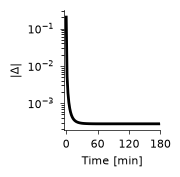

In [9]:
err = np.stack([phase_results[s][PRETRAIN]['mean_abs_balance_error'] for s in SEEDS])
t_pretrain = phase_results[SEEDS[0]][PRETRAIN]['training_time']
mean, std = err.mean(0), err.std(0)

fig, ax = plt.subplots(1, 1, figsize=figsize_balance, constrained_layout=True)
ax.plot(t_pretrain, mean, lw=2.0, color='black')
ax.fill_between(t_pretrain, np.maximum(mean - std, 0.0), mean + std, color='gray', alpha=0.3, linewidth=0.0)
ax.set_xlabel('Time [min]')
ax.set_ylabel(r'$|\Delta|$')
ax.set_yscale('log')
ax.set_xlim(*xlim_pretrain)
ax.set_xticks(xticks_pretrain)

plt.savefig(sfig6_dir / "b_balance_error.pdf")
plt.show()

### Panel c: example I-to-E weights during plasticity

In [10]:
TRACE_SEED = 5
N_TRACKED_WEIGHTS = 20
figsize_traces = (4.3*cm, 4.2*cm)
ylim_traces = (0, 0.2)

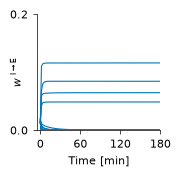

In [11]:
traces = phase_results[TRACE_SEED][PRETRAIN]['W_IE']  # [recordings, inh, exc]
traces = traces.reshape(traces.shape[0], -1)
nonzero_final = np.where(traces[-1] > 0.0)[0]
sel = np.random.default_rng(TRACE_SEED).choice(nonzero_final, size=N_TRACKED_WEIGHTS, replace=False)

fig, ax = plt.subplots(1, 1, figsize=figsize_traces, constrained_layout=True)
ax.plot(phase_results[TRACE_SEED][PRETRAIN]['training_time'], traces[:, sel], color=color_inh, lw=0.8)
ax.set_ylim(*ylim_traces)
ax.set_yticks(list(ylim_traces))
ax.set_ylabel(r'$w^{\ \mathrm{I}\rightarrow \mathrm{E}}$', labelpad=-10)
ax.set_xlabel('Time [min]')
ax.set_xlim(*xlim_pretrain)
ax.set_xticks(xticks_pretrain)

plt.savefig(sfig6_dir / "c_wie_traces.pdf")
plt.show()

### Panel d: final balance error

In [12]:
figsize_final_balance = (4*cm, 4.2*cm)

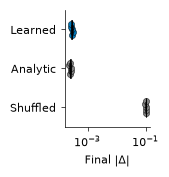

In [13]:
fig, ax = plt.subplots(figsize=figsize_final_balance, constrained_layout=True)
for pos, (name, color) in enumerate([('shuffled', 'gray'), ('analytic', 'gray'), ('learned', color_inh)]):
    data = balance_error[name]
    ax.boxplot([data], positions=[pos], widths=0.5, orientation='horizontal', patch_artist=True, showfliers=False,
               boxprops=dict(facecolor=to_rgba(color, 0.3), edgecolor='black', linewidth=0.5),
               whiskerprops=dict(linewidth=0.5, color='black'),
               medianprops=dict(linewidth=0.75, color='black'),
               capprops=dict(linewidth=0.5, color='black'))
    ax.scatter(data, np.linspace(pos - 0.15, pos + 0.15, len(data)), s=20, color=color,
               edgecolor='black', linewidth=0.3)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Shuffled', 'Analytic', 'Learned'])
ax.set_xlabel(r'Final $|\Delta|$')
ax.set_xscale('log')

plt.savefig(sfig6_dir / 'd_final_balance_error.pdf')
plt.show()

### Panel e: learned and analytic I-to-E weights

In [14]:
MATRIX_SEED = 2
ZOOM_INH = (3, 12)
ZOOM_EXC = (12, 48)
figsize_matrices = (9*cm, 4*cm)
figsize_zoom = (2*cm, 4*cm)

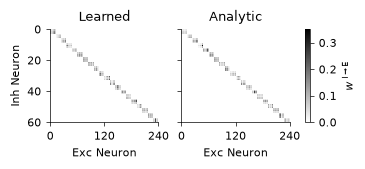

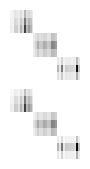

In [15]:
vmax = max(max(w.max() for w in learned_wie.values()), max(w.max() for w in analytic_wie.values()))
matrices = {'Learned': learned_wie[MATRIX_SEED], 'Analytic': analytic_wie[MATRIX_SEED]}

fig, axs = plt.subplots(1, 2, figsize=figsize_matrices)
for ax, (title, W) in zip(axs, matrices.items()):
    im = ax.pcolormesh(np.arange(W.shape[1] + 1), np.arange(W.shape[0] + 1), W, cmap='binary',
                       vmin=0.0, vmax=vmax, shading='flat', antialiased=False)
    ax.set_xlim(0, W.shape[1])
    ax.set_ylim(0, W.shape[0])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Exc Neuron')
    ax.set_xticks([0, 120, 240])
axs[0].set_ylabel('Inh Neuron')
axs[1].set_yticklabels([])
fig.colorbar(im, ax=axs, fraction=0.045, pad=0.02, label=r'$w^{\ \mathrm{I}\rightarrow \mathrm{E}}$')

plt.savefig(sfig6_dir / "e_wie_matrices.pdf", bbox_inches='tight')
plt.show()

fig, axs = plt.subplots(2, 1, figsize=figsize_zoom)
for ax, W in zip(axs, matrices.values()):
    ax.pcolormesh(np.arange(ZOOM_EXC[0], ZOOM_EXC[1] + 1), np.arange(ZOOM_INH[0], ZOOM_INH[1] + 1),
                  W[slice(*ZOOM_INH), slice(*ZOOM_EXC)], cmap='binary', vmin=0.0, vmax=vmax,
                  shading='flat', antialiased=False)
    ax.set_xlim(*ZOOM_EXC)
    ax.set_ylim(*ZOOM_INH)
    ax.invert_yaxis()
    ax.axis('off')

plt.savefig(sfig6_dir / "e_wie_matrices_zoom.pdf", bbox_inches='tight')
plt.show()

### Panel f: output trajectory after learning

In [16]:
TRAJ_SEED = 5
figsize_traj = (2*cm, 2*cm)

In [17]:
cfg, task, vf = rebuild_traj_run(HydraRunOutput(learned_dir / f"seed{TRAJ_SEED}"), shapes_dir)
sim = SimulationRunner(vf, Euler(), ConstantStepSize(), cfg.dt, cfg.rec_dt, cfg.T)
x_eval, y_eval, x_eval_interp, _ = task.simulate()
_, sol_eval = sim.run_mode(dict(phase_states[TRAJ_SEED][MAIN]), x_eval_interp, None,
                           sim.mode_open_loop, save_final_only=False, phase_iter=0)

/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg


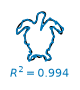

In [18]:
fig, ax = plt.subplots(1, 1, figsize=figsize_traj)
OL_out = sol_eval.ys['uOut'][:, 0, :]
ax.plot(OL_out[:, 0], OL_out[:, 1], color=color_inh, lw=linewidth)
ax.plot(y_eval[:, 0], y_eval[:, 1], color=color_target, lw=linewidth, zorder=-1)

ax.axis('off')
ax.set_aspect('equal', adjustable='box', anchor='SE')
ax.text(0.5, -0.05, rf'$R^2={learned_R2s[SEEDS.index(TRAJ_SEED)]:.3f}$',
        fontsize=8, color=color_inh, ha='center', va='top', transform=ax.transAxes)

plt.savefig(sfig6_dir / 'f_trajectory_after.pdf', bbox_inches='tight')
plt.show()

### Panel g: final open-loop $R^2$

In [19]:
figsize_r2 = (5*cm, 4*cm)
ylim_r2 = (0.98, 1.0)

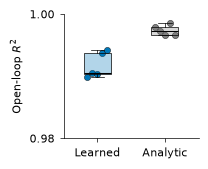

In [20]:
fig, ax = plt.subplots(figsize=figsize_r2, constrained_layout=True)
for pos, (data, color) in enumerate([(learned_R2s, color_inh), (analytic_R2s, 'gray')]):
    ax.boxplot([data], positions=[pos], widths=0.4, patch_artist=True, showfliers=False,
               boxprops=dict(facecolor=to_rgba(color, 0.3), edgecolor='black', linewidth=0.5),
               whiskerprops=dict(linewidth=0.5, color='black'),
               medianprops=dict(linewidth=0.75, color='black'),
               capprops=dict(linewidth=0.5, color='black'))
    ax.scatter(np.linspace(pos - 0.15, pos + 0.15, len(data)), data, s=20, color=color,
               edgecolor='black', linewidth=0.3)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Learned', 'Analytic'])
ax.set_ylabel(r'Open-loop $R^2$')
ax.set_ylim(*ylim_r2)
ax.set_yticks(list(ylim_r2))

plt.savefig(sfig6_dir / "g_final_r2.pdf")
plt.show()